In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
stores = pd.read_csv("/content/stores(1)(1).csv")
sales = pd.read_csv("/content/sales(1).csv")
products = pd.read_csv("/content/products(1)(1).csv")
customers = pd.read_csv("/content/customers(1).csv")

sales.head()

,SaleID,CustomerID,ProductID,StoreID,SaleDate,Quantity,UnitPrice,TotalAmount,PaymentMethod,DeliveryStatus
0,1,8,19,6,2024-08-09,1,673.00,673.00,Wallet,Cancelled
1,2,2,16,2,2024-05-27,1,135.37,135.37,Cash,Delivered
2,3,51,42,3,2025-05-05,4,1249.41,4997.64,Wallet,Cancelled
3,4,51,46,8,2023-12-16,1,1892.48,1892.48,Cash,Delivered
4,5,23,11,7,2024-01-16,3,380.45,1141.35,Wallet,Pending


In [3]:
print("Sales Shape:", sales.shape)
print("Stores Shape:", stores.shape)
print("Products Shape:", products.shape)
print("Customers Shape:", customers.shape)

Sales Shape: (350, 10)
Stores Shape: (100, 6)
Products Shape: (150, 6)
Customers Shape: (100, 11)


In [7]:
print("Sales Shape:", sales.info())
print("Stores Shape:", stores.info())
print("Products Shape:", products.info())
print("Customers Shape:", customers.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SaleID          350 non-null    int64  
 1   CustomerID      350 non-null    int64  
 2   ProductID       350 non-null    int64  
 3   StoreID         350 non-null    int64  
 4   SaleDate        350 non-null    object 
 5   Quantity        350 non-null    int64  
 6   UnitPrice       350 non-null    float64
 7   TotalAmount     350 non-null    float64
 8   PaymentMethod   350 non-null    object 
 9   DeliveryStatus  350 non-null    object 
dtypes: float64(2), int64(5), object(3)
memory usage: 27.5+ KB
Sales Shape: None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   StoreID    100 non-null    int64 
 1   StoreName  100 non-null    object
 2   Location  

In [8]:
df = sales.merge(products, on="ProductID") \
          .merge(stores, on="StoreID") \
          .merge(customers, on="CustomerID")

df.head()

,SaleID,CustomerID,ProductID,StoreID,SaleDate,Quantity,UnitPrice,TotalAmount,PaymentMethod,DeliveryStatus,...,FirstName,LastName,Email,Phone,Gender,Age,City,State,Country,LoyaltyScore
0,1,8,19,6,2024-08-09,1,673.00,673.00,Wallet,Cancelled,...,Pamela,Gibson,asmith@gmail.com,(586)158-7523,M,37,Edwardsbury,Washington,Isle of Man,75.0
1,2,2,16,2,2024-05-27,1,135.37,135.37,Cash,Delivered,...,Sue,Foster,krystalreed@skinner-fleming.com,001-626-141-0170x53874,M,64,North Kristen,Louisiana,Saint Vincent and the Grenadines,62.0
2,3,51,42,3,2025-05-05,4,1249.41,4997.64,Wallet,Cancelled,...,Barbara,Carter,danielreed@yahoo.com,NaN,M,18,New Benjamin,New Hampshire,Hong Kong,NaN
3,4,51,46,8,2023-12-16,1,1892.48,1892.48,Cash,Delivered,...,Barbara,Carter,danielreed@yahoo.com,NaN,M,18,New Benjamin,New Hampshire,Hong Kong,NaN
4,5,23,11,7,2024-01-16,3,380.45,1141.35,Wallet,Pending,...,Timothy,Joseph,christophermoore@yahoo.com,(491)056-5023,M,45,Lake Taylor,Kansas,Zimbabwe,NaN


In [9]:
df.shape

(350, 30)

In [10]:
df.isnull().sum()

,0
SaleID,0
CustomerID,0
ProductID,0
StoreID,0
SaleDate,0
Quantity,0
UnitPrice,0
TotalAmount,0
PaymentMethod,0
DeliveryStatus,0


In [12]:
df["SaleDate"] = pd.to_datetime(df["SaleDate"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   SaleID          350 non-null    int64         
 1   CustomerID      350 non-null    int64         
 2   ProductID       350 non-null    int64         
 3   StoreID         350 non-null    int64         
 4   SaleDate        350 non-null    datetime64[ns]
 5   Quantity        350 non-null    int64         
 6   UnitPrice       350 non-null    float64       
 7   TotalAmount     350 non-null    float64       
 8   PaymentMethod   350 non-null    object        
 9   DeliveryStatus  350 non-null    object        
 10  ProductName     350 non-null    object        
 11  Category        350 non-null    object        
 12  Price           350 non-null    float64       
 13  StockQty        350 non-null    int64         
 14  Supplier        350 non-null    object        
 15  StoreN

**Sales Distribution**

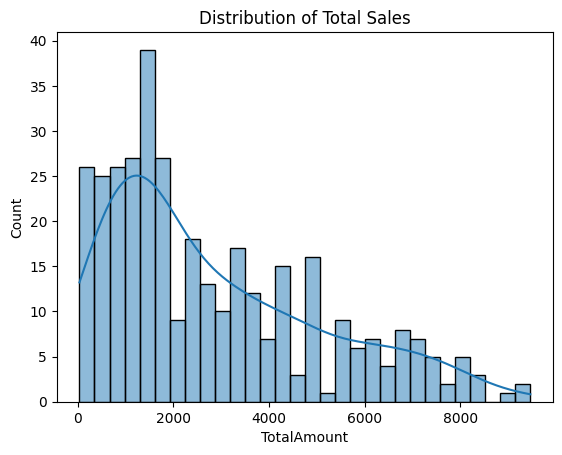

In [13]:
sns.histplot(df["TotalAmount"], bins=30, kde=True)
plt.title("Distribution of Total Sales")
plt.show()

**Revenue by Category**

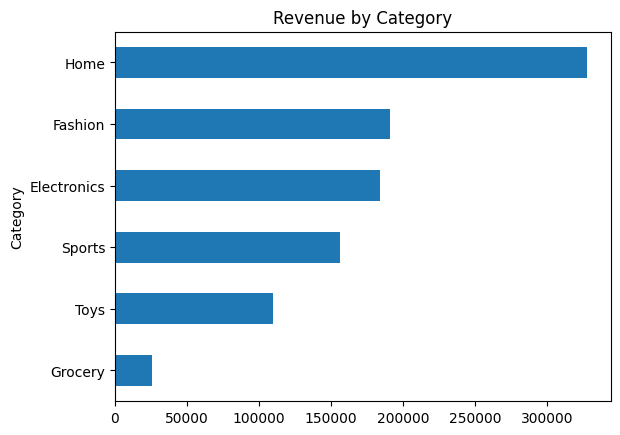

In [14]:
category_sales = df.groupby("Category")["TotalAmount"].sum().sort_values()

category_sales.plot(kind="barh")
plt.title("Revenue by Category")
plt.show()

**Category vs Location (Heatmap)**

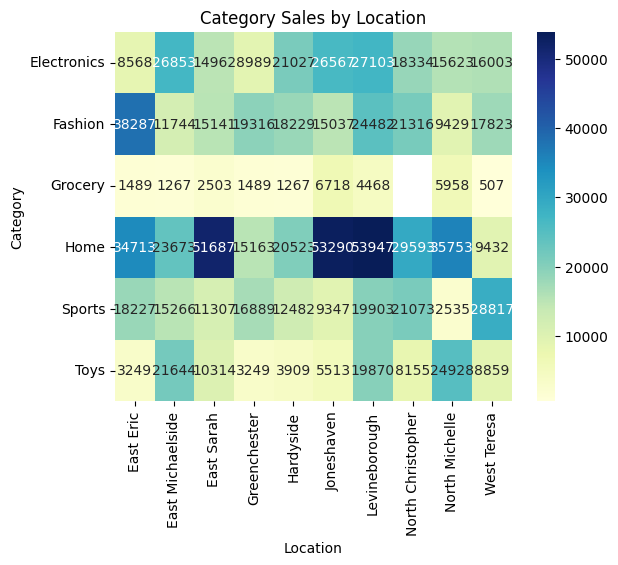

In [25]:
pivot = df.pivot_table(values="TotalAmount",
                       index="Category",
                       columns="Location",
                       aggfunc="sum")

sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Category Sales by Location")
plt.show()

**Top 10 Products**

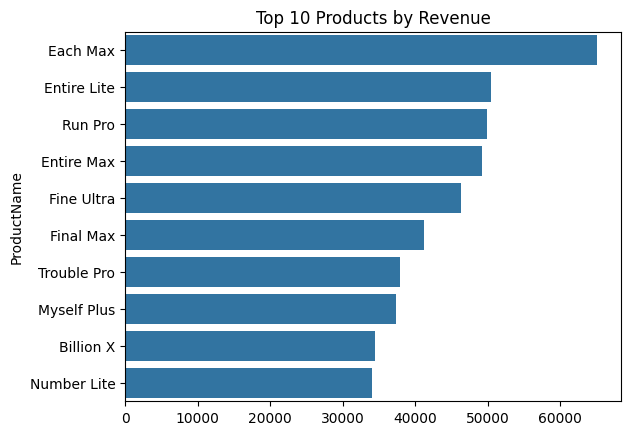

In [15]:
top_products = df.groupby("ProductName")["TotalAmount"].sum().nlargest(10)

sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Revenue")
plt.show()

Correelation Matrix

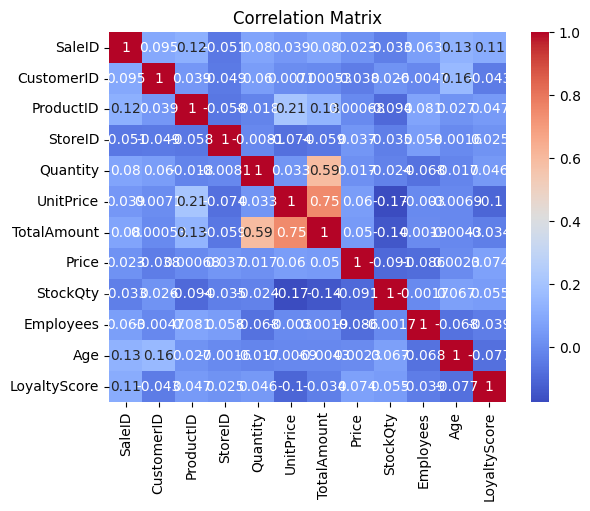

In [27]:
numeric_cols = df.select_dtypes(include=np.number)

sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**Revenue by Store**

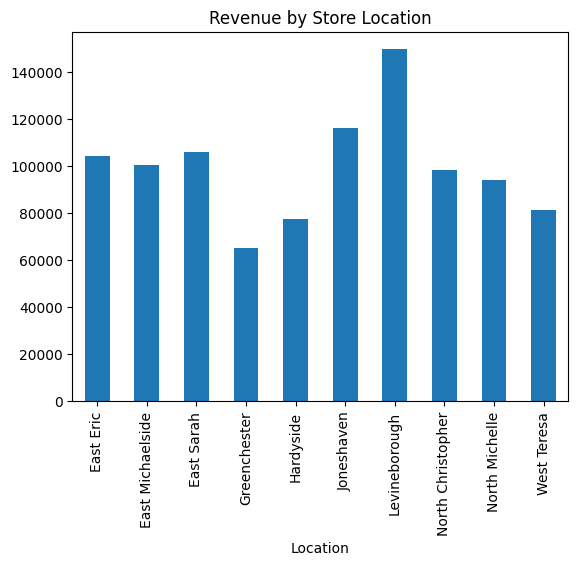

In [16]:
store_sales = df.groupby("Location")["TotalAmount"].sum()

store_sales.plot(kind="bar")
plt.title("Revenue by Store Location")
plt.show()

**Gender vs spending**

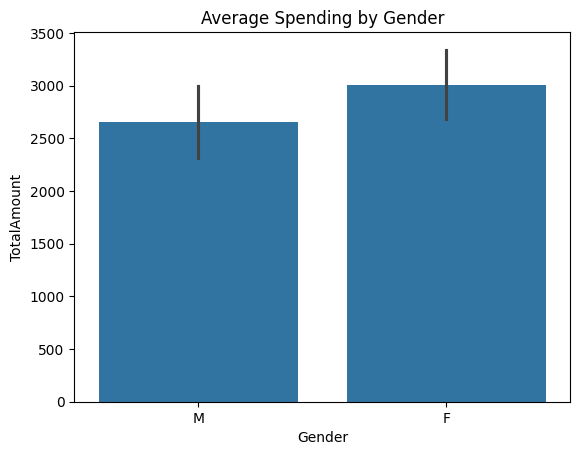

In [17]:
sns.barplot(x="Gender", y="TotalAmount", data=df)
plt.title("Average Spending by Gender")
plt.show()

**Age vs sales**

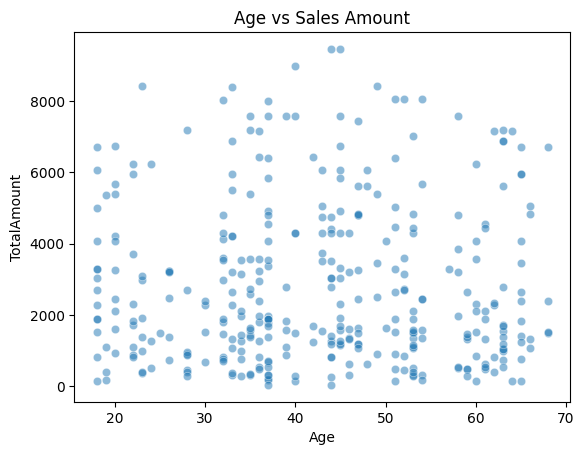

In [18]:
sns.scatterplot(x="Age", y="TotalAmount", data=df, alpha=0.5)
plt.title("Age vs Sales Amount")
plt.show()

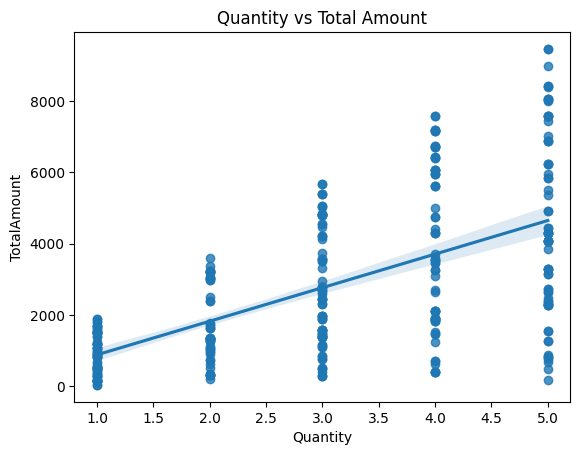

In [19]:
sns.regplot(x="Quantity", y="TotalAmount", data=df)
plt.title("Quantity vs Total Amount")
plt.show()

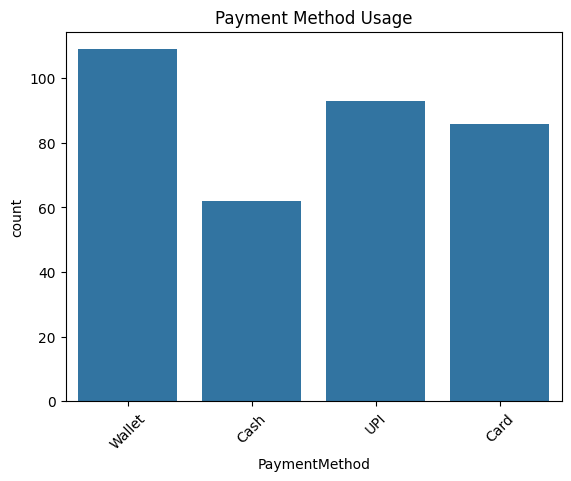

In [20]:
sns.countplot(x="PaymentMethod", data=df)
plt.title("Payment Method Usage")
plt.xticks(rotation=45)
plt.show()

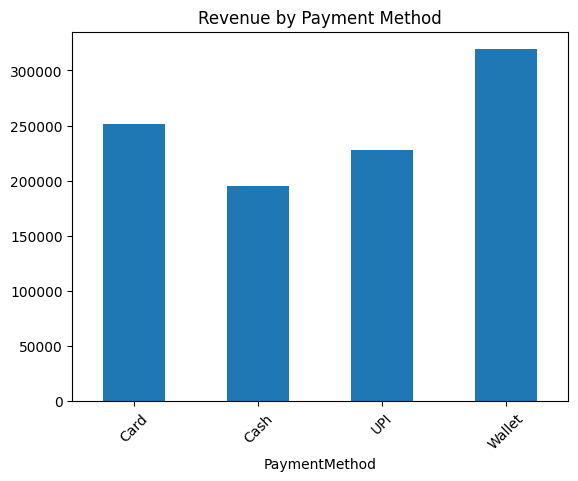

In [21]:
payment_sales = df.groupby("PaymentMethod")["TotalAmount"].sum()

payment_sales.plot(kind="bar")
plt.title("Revenue by Payment Method")
plt.xticks(rotation=45)
plt.show()

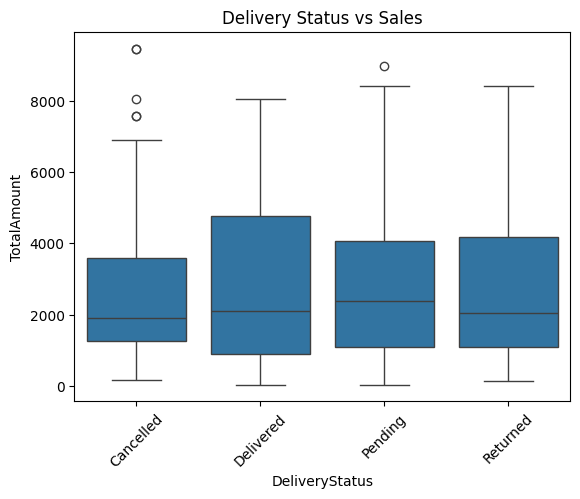

In [22]:
sns.boxplot(x="DeliveryStatus", y="TotalAmount", data=df)
plt.title("Delivery Status vs Sales")
plt.xticks(rotation=45)
plt.show()

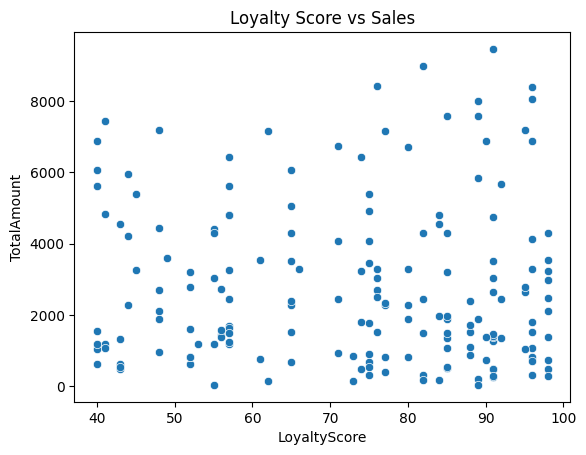

In [23]:
sns.scatterplot(x="LoyaltyScore", y="TotalAmount", data=df)
plt.title("Loyalty Score vs Sales")
plt.show()

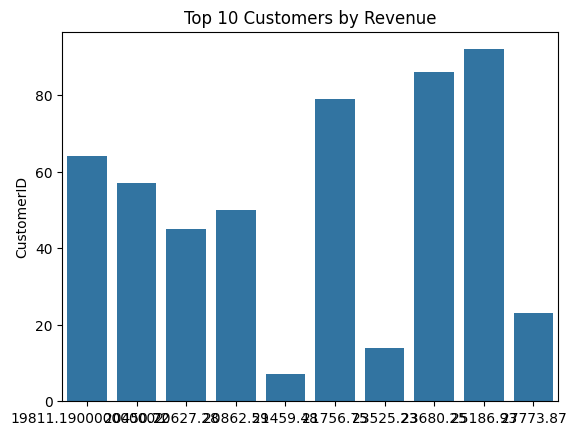

In [24]:
top_customers = df.groupby("CustomerID")["TotalAmount"].sum().nlargest(10)

sns.barplot(x=top_customers.values, y=top_customers.index)
plt.title("Top 10 Customers by Revenue")
plt.show()

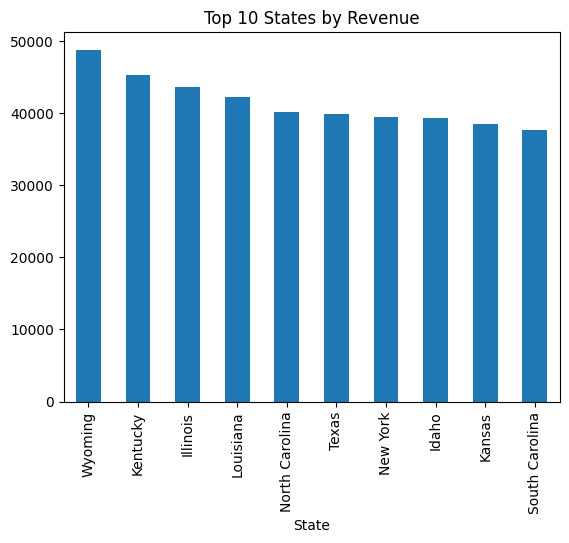

In [28]:
state_sales = df.groupby("State")["TotalAmount"].sum().sort_values(ascending=False)

state_sales.head(10).plot(kind="bar")
plt.title("Top 10 States by Revenue")
plt.show()

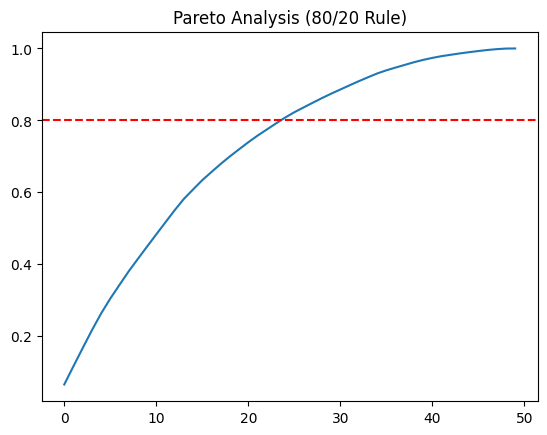

In [29]:
product_sales = df.groupby("ProductName")["TotalAmount"].sum().sort_values(ascending=False)
cumulative = product_sales.cumsum() / product_sales.sum()

plt.plot(cumulative.values)
plt.axhline(0.8, color="r", linestyle="--")
plt.title("Pareto Analysis (80/20 Rule)")
plt.show()